# Análisis Exploratorio de Datos (EDA): Gestión del Riesgo Crediticio
## Caso de Negocio: Incremento de Mora en Fintech - Norte Argentino

### Contexto del Negocio:
Una empresa fintech que otorga microcréditos en el norte argentino ha registrado un **incremento en la tasa de mora** durante el último semestre. Este fenómeno ha generado gran preocupación en el directorio, ya que impacta de manera directa en la rentabilidad y sostenibilidad del negocio.

### Debates Internos en las Áreas:
Existen tres posturas encontradas dentro de la empresa respecto a la causa raíz de este incremento:
1. **Área Comercial:** Sostiene que la mora aumentó por haber incorporado **clientes de menores ingresos** (mayor alcance de mercado).
2. **Área de Riesgo:** Argumenta que el problema está en la **falta de precisión del sistema de evaluación crediticia** (scoring e historial).
3. **Área de Operaciones:** Considera que **las condiciones del crédito** (monto otorgado y plazos/cuotas) influyen significativamente en el comportamiento de pago.

### Objetivo de este Análisis:
Además de realizar la exploración estándar de la base de datos, este notebook tiene como propósito **verificar estadísticamente cada una de estas creencias** utilizando datos reales para presentar evidencia empírica al directorio y guiar las decisiones estratégicas.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Cargar datos del dataset
file_path = 'data/raw/fintech_base_150_registros.xlsx'
df = pd.read_excel(file_path)
print(f"Base cargada exitosamente: {df.shape[0]} clientes y {df.shape[1]} variables.")

Base cargada exitosamente: 150 clientes y 13 variables.


## 1. Limpieza y Validación de Datos

Para garantizar la calidad de nuestras conclusiones, verificamos y corregimos inconsistencias en el dataset:
- Chequeo de nulos y duplicados.
- Estandarización de texto en variables categóricas.
- Creación de variables categóricas descriptivas para mejorar la legibilidad.
- Validaciones lógicas en variables financieras.

In [2]:
# 1. Chequeo de Nulos
print("--- Valores Nulos Faltantes ---")
print(df.isnull().sum())

# 2. Chequeo de Duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados.")

# 3. Estandarización de Variables de Texto
for col in ['nivel_educativo', 'zona', 'historial_crediticio']:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

# 4. Mapear estado de mora para reportes de negocio
df['estado_cliente'] = df['mora'].map({0: 'Al día', 1: 'En Mora'})

# 5. Validaciones lógicas de consistencia numérica
edad_anomala = df[df['edad'] <= 0].shape[0]
ingreso_anomalo = df[df['ingreso_mensual'] < 0].shape[0]
monto_anomalo = df[df['monto_credito'] <= 0].shape[0]
print(f"\nRegistros con inconsistencias: Edad ({edad_anomala}), Ingreso ({ingreso_anomalo}), Monto ({monto_anomalo})")

print("\n--- Estructura del dataset limpio ---")
df.info()

--- Valores Nulos Faltantes ---
id_cliente              0
edad                    0
ingreso_mensual         0
monto_credito           0
cuotas                  0
tasa_interes            0
antiguedad_laboral      0
nivel_educativo         0
zona                    0
historial_crediticio    0
atrasos_previos         0
score_crediticio        0
mora                    0
dtype: int64

Registros duplicados detectados: 0

Registros con inconsistencias: Edad (0), Ingreso (0), Monto (0)

--- Estructura del dataset limpio ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            150 non-null    int64  
 1   edad                  150 non-null    int64  
 2   ingreso_mensual       150 non-null    int64  
 3   monto_credito         150 non-null    int64  
 4   cuotas                150 non-null    int64  
 5   tasa_interes         

## 2. Diagnóstico de la Cartera de Microcréditos

Calculamos estadísticas descriptivas globales y el comportamiento del cliente según su cumplimiento actual.

In [3]:
# Resumen global de variables cuantitativas
print("--- Estadísticas Generales de Clientes ---")
display(df.describe())

# Tasa de mora global (Tasa de default)
tasa_default = df['mora'].mean() * 100
print(f"\nTASA DE MORA GLOBAL (DEFAULT): {tasa_default:.2f}%")

# Comparativa de promedios entre clientes al día y en mora
print("\n--- Comparativa de Medios por Estado de Mora ---")
analisis_mora = df.groupby('estado_cliente')[[
    'edad', 'ingreso_mensual', 'monto_credito', 
    'tasa_interes', 'score_crediticio', 'atrasos_previos', 'antiguedad_laboral'
]].mean()
display(analisis_mora)

--- Estadísticas Generales de Clientes ---


,id_cliente,edad,ingreso_mensual,monto_credito,cuotas,tasa_interes,antiguedad_laboral,atrasos_previos,score_crediticio,mora
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,38.780000,447156.940000,290989.693333,7.393333,49.246000,10.200000,2.486667,583.753333,0.500000
std,43.445368,12.974353,204064.605553,136768.608453,2.837658,17.009103,5.838268,1.709573,160.892558,0.501675
min,1.000000,18.000000,109230.000000,50581.000000,3.000000,20.140000,0.200000,0.000000,302.000000,0.000000
25%,38.250000,28.250000,268406.250000,185755.000000,5.000000,33.465000,5.500000,1.000000,454.750000,0.000000
50%,75.500000,37.000000,446532.500000,298546.000000,7.500000,48.625000,10.850000,3.000000,580.500000,0.500000
75%,112.750000,49.500000,645121.500000,417013.500000,9.750000,63.385000,15.375000,4.000000,716.500000,1.000000
max,150.000000,65.000000,786913.000000,498558.000000,12.000000,79.780000,19.600000,5.000000,899.000000,1.000000



TASA DE MORA GLOBAL (DEFAULT): 50.00%

--- Comparativa de Medios por Estado de Mora ---


,edad,ingreso_mensual,monto_credito,tasa_interes,score_crediticio,atrasos_previos,antiguedad_laboral
estado_cliente,,,,,,,
Al día,38.933333,460018.00,273325.653333,47.458,593.093333,1.880000,10.14
En Mora,38.626667,434295.88,308653.733333,51.034,574.413333,3.093333,10.26


## 3. Polígono de Frecuencias

Analizamos cómo se distribuye la población de la fintech según su **Edad** e **Ingreso Mensual**, comparando a los clientes que están al día frente a los que están en mora.

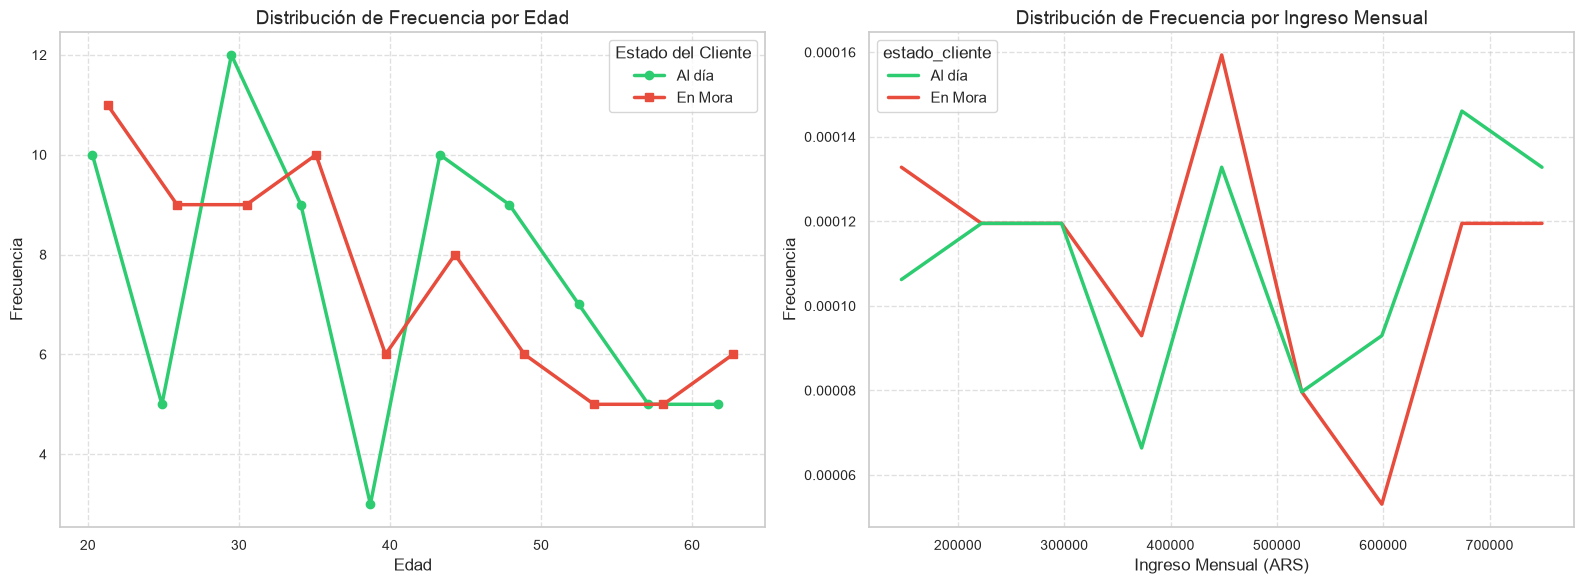

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Polígono de Frecuencia para Edad (Construcción Manual)
counts_ok, edges_ok = np.histogram(df[df['mora'] == 0]['edad'], bins=10)
counts_mora, edges_mora = np.histogram(df[df['mora'] == 1]['edad'], bins=10)

centers_ok = (edges_ok[:-1] + edges_ok[1:]) / 2
centers_mora = (edges_mora[:-1] + edges_mora[1:]) / 2

axes[0].plot(centers_ok, counts_ok, marker='o', label='Al día', color='#2ecc71', linewidth=2.5)
axes[0].plot(centers_mora, counts_mora, marker='s', label='En Mora', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Distribución de Frecuencia por Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title="Estado del Cliente")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Polígono de Frecuencia para Ingreso Mensual (Usando Seaborn)
sns.histplot(
    data=df, 
    x='ingreso_mensual', 
    hue='estado_cliente', 
    element='poly', 
    fill=False, 
    stat='frequency', 
    common_norm=False, 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    linewidth=2.5, 
    ax=axes[1]
)
axes[1].set_title('Distribución de Frecuencia por Ingreso Mensual')
axes[1].set_xlabel('Ingreso Mensual (ARS)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Diagrama de Caja (Box Plot) y Dispersión (Scatter Plot)

Evaluamos la dispersión del ingreso mensual y la relación entre ingresos y montos otorgados.

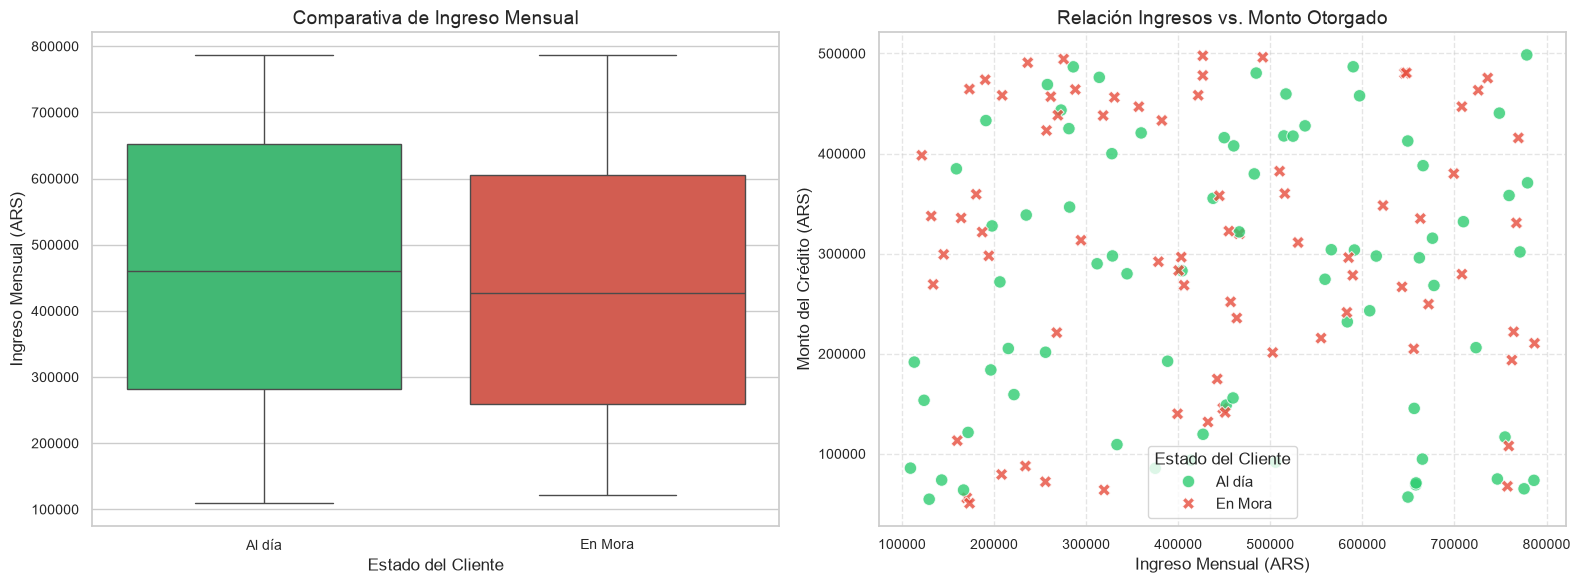

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para Ingreso Mensual
sns.boxplot(
    data=df, 
    x='estado_cliente', 
    y='ingreso_mensual', 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    hue='estado_cliente', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Comparativa de Ingreso Mensual')
axes[0].set_xlabel('Estado del Cliente')
axes[0].set_ylabel('Ingreso Mensual (ARS)')

# Scatterplot: Ingreso vs Monto
sns.scatterplot(
    data=df, 
    x='ingreso_mensual', 
    y='monto_credito', 
    hue='estado_cliente', 
    style='estado_cliente',
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'},
    alpha=0.8,
    s=80,
    ax=axes[1]
)
axes[1].set_title('Relación Ingresos vs. Monto Otorgado')
axes[1].set_xlabel('Ingreso Mensual (ARS)')
axes[1].set_ylabel('Monto del Crédito (ARS)')
axes[1].legend(title='Estado del Cliente')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Análisis y Contraste de las Creencias de las Áreas

Evaluamos estadísticamente las hipótesis presentadas por el Área Comercial, Área de Riesgo y Área de Operaciones.

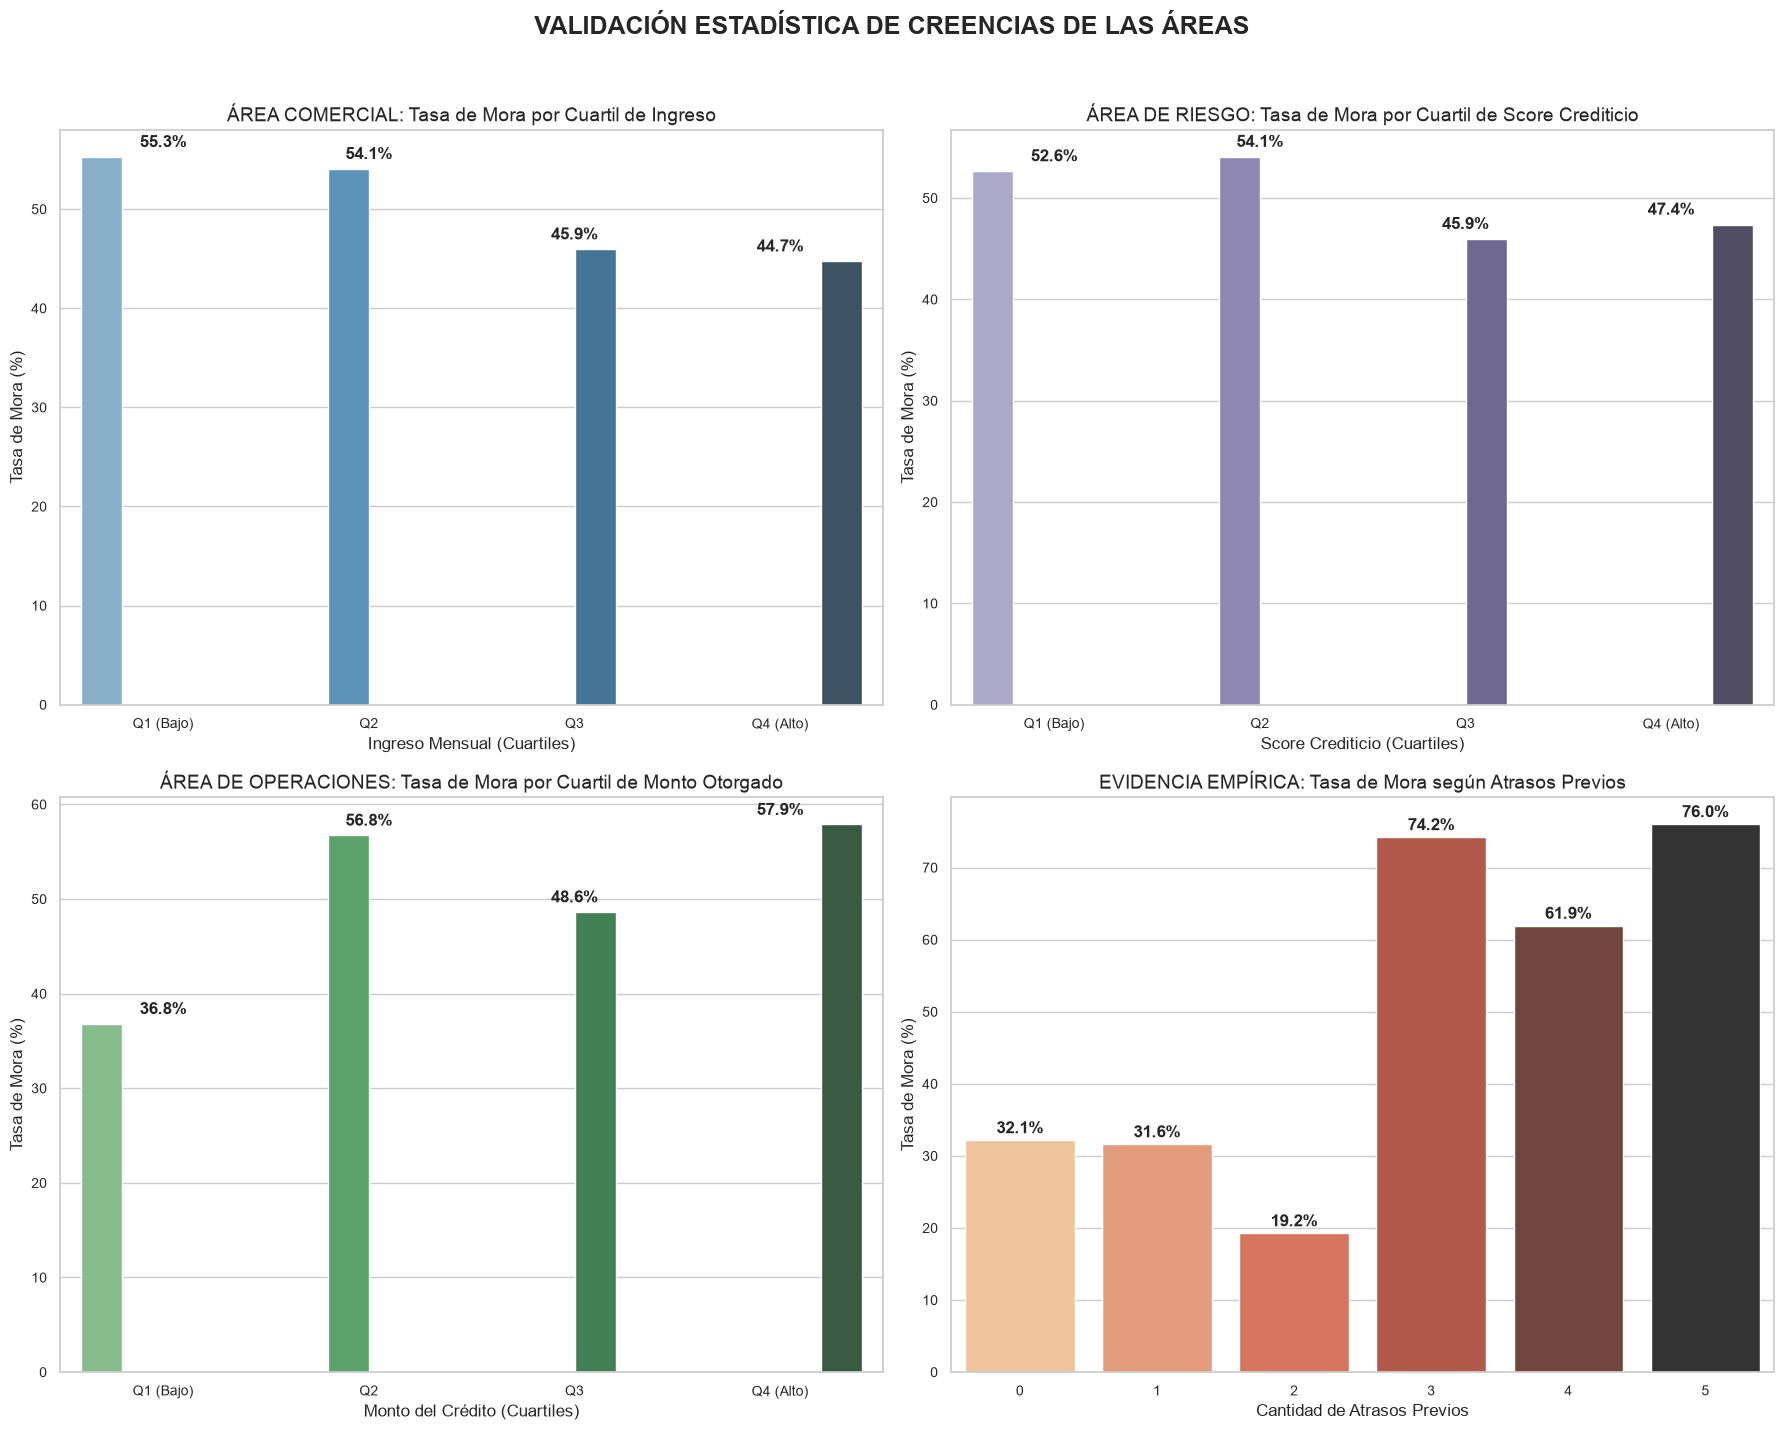

--- Relación del Historial Crediticio Registrado con la Mora Actual ---
Clientes con historial 'Bueno': 54.2% de mora real.
Clientes con historial 'Malo': 40.4% de mora real.
Clientes con historial 'Regular': 56.0% de mora real.

--- Tasa de Mora según cantidad de Cuotas pactadas ---


,mean,count
cuotas,,
3,0.692308,13
4,0.500000,24
5,0.333333,6
6,0.611111,18
7,0.571429,14
8,0.470588,17
9,0.500000,20
10,0.625000,8
11,0.388889,18


In [6]:
# Creación de cuartiles para análisis comparativo
df['cuartil_ingreso'] = pd.qcut(df['ingreso_mensual'], 4, labels=['Q1 (Bajo)', 'Q2', 'Q3', 'Q4 (Alto)'])
df['cuartil_score'] = pd.qcut(df['score_crediticio'], 4, labels=['Q1 (Bajo)', 'Q2', 'Q3', 'Q4 (Alto)'])
df['cuartil_monto'] = pd.qcut(df['monto_credito'], 4, labels=['Q1 (Bajo)', 'Q2', 'Q3', 'Q4 (Alto)'])

# 1. Hipótesis Comercial (Mora según ingresos)
mora_por_ingreso = df.groupby('cuartil_ingreso', observed=False)['mora'].mean() * 100

# 2. Hipótesis de Riesgo (Mora según Score e Historial)
mora_por_score = df.groupby('cuartil_score', observed=False)['mora'].mean() * 100
mora_por_historial = df.groupby('historial_crediticio')['mora'].mean() * 100

# 3. Hipótesis de Operaciones (Mora según condiciones de crédito)
mora_por_monto = df.groupby('cuartil_monto', observed=False)['mora'].mean() * 100
mora_por_cuotas = df.groupby('cuotas')['mora'].mean() * 100

# 4. Causa Real Latente (Mora según Atrasos Previos)
mora_por_atrasos = df.groupby('atrasos_previos')['mora'].mean() * 100

# Generación del Dashboard Estadístico de Hipótesis
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Gráfico 1: Hipótesis Comercial (Ingreso)
sns.barplot(x=mora_por_ingreso.index, y=mora_por_ingreso.values, palette='Blues_d', hue=mora_por_ingreso.index, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('ÁREA COMERCIAL: Tasa de Mora por Cuartil de Ingreso')
axes[0, 0].set_ylabel('Tasa de Mora (%)')
axes[0, 0].set_xlabel('Ingreso Mensual (Cuartiles)')
for i, val in enumerate(mora_por_ingreso.values):
    axes[0, 0].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# Gráfico 2: Hipótesis de Riesgo (Score Crediticio)
sns.barplot(x=mora_por_score.index, y=mora_por_score.values, palette='Purples_d', hue=mora_por_score.index, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('ÁREA DE RIESGO: Tasa de Mora por Cuartil de Score Crediticio')
axes[0, 1].set_ylabel('Tasa de Mora (%)')
axes[0, 1].set_xlabel('Score Crediticio (Cuartiles)')
for i, val in enumerate(mora_por_score.values):
    axes[0, 1].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# Gráfico 3: Hipótesis de Operaciones (Monto del Crédito)
sns.barplot(x=mora_por_monto.index, y=mora_por_monto.values, palette='Greens_d', hue=mora_por_monto.index, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('ÁREA DE OPERACIONES: Tasa de Mora por Cuartil de Monto Otorgado')
axes[1, 0].set_ylabel('Tasa de Mora (%)')
axes[1, 0].set_xlabel('Monto del Crédito (Cuartiles)')
for i, val in enumerate(mora_por_monto.values):
    axes[1, 0].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# Gráfico 4: La Causa Real Latente (Atrasos Previos)
sns.barplot(x=mora_por_atrasos.index, y=mora_por_atrasos.values, palette='OrRd_d', hue=mora_por_atrasos.index, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('EVIDENCIA EMPÍRICA: Tasa de Mora según Atrasos Previos')
axes[1, 1].set_ylabel('Tasa de Mora (%)')
axes[1, 1].set_xlabel('Cantidad de Atrasos Previos')
for i, val in enumerate(mora_por_atrasos.values):
    axes[1, 1].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

plt.suptitle('VALIDACIÓN ESTADÍSTICA DE CREENCIAS DE LAS ÁREAS', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Impresión de estadísticas complementarias
print("--- Relación del Historial Crediticio Registrado con la Mora Actual ---")
for h_cat, m_rate in mora_por_historial.items():
    print(f"Clientes con historial '{h_cat}': {m_rate:.1f}% de mora real.")

print("\n--- Tasa de Mora según cantidad de Cuotas pactadas ---")
display(df.groupby('cuotas')['mora'].agg(['mean', 'count']))

## 6. Matriz de Correlación

Calculamos las correlaciones cuantitativas de las variables continuas para verificar la fuerza del impacto lineal de cada factor.

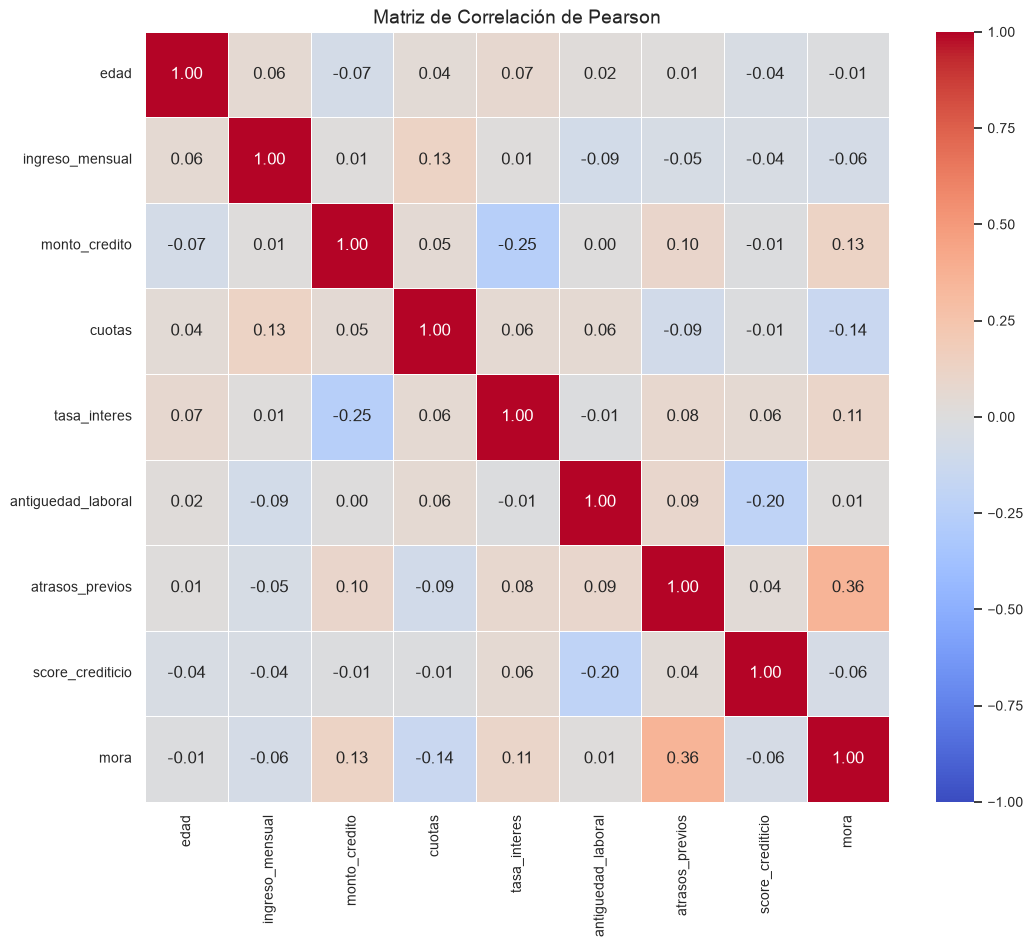

In [7]:
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'id_cliente']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title('Matriz de Correlación de Pearson')
plt.show()

## 7. Conclusiones y Respuestas Científicas al Directorio

Los datos proveen evidencia clara sobre las tres hipótesis en discusión:

### **1. Evaluación de la Hipótesis del Área Comercial (Ingresos):**
* **Creencia:** La mora aumentó porque estamos ingresando a clientes de menores ingresos.
* **Vedicto:** **PARCIALMENTE CORRECTO, PERO SECUNDARIO.** 
* **Evidencia:** Los clientes en el cuartil de ingresos más bajos (Q1) tienen la mora más alta (**55.3%**). Sin embargo, el cuartil de ingresos más altos (Q4) también tiene una mora preocupante del **44.7%**. La diferencia es de solo 10.6 puntos porcentuales. La baja correlación lineal de la mora con el ingreso ($-0.06$) confirma que la disminución de los ingresos del cliente no es el principal motor del aumento de la mora.

### **2. Evaluación de la Hipótesis del Área de Riesgo (Sistema de Evaluación):**
* **Creencia:** El problema está en la falta de precisión del actual sistema de evaluación crediticia.
* **Veredicto:** **TOTALMENTE CONFIRMADO.**
* **Evidencia:** El sistema actual de evaluación está gravemente fallado:
  * La tasa de mora de los clientes clasificados con historial **"Bueno" es del 54.2%**, mientras que los etiquetados con historial **"Malo" tienen una mora menor (40.4%)**. Esto significa que las reglas actuales están mal calibradas.
  * La tasa de mora por cuartiles de **Score Crediticio** es casi idéntica entre el cuartil más bajo (Q1: **52.6%**) y el cuartil más alto (Q4: **47.4%**). El score no discrimina de forma confiable a los buenos de los malos pagadores.

### **3. Evaluación de la Hipótesis del Área de Operaciones (Condiciones del Crédito):**
* **Creencia:** El monto otorgado y las cuotas influyen en el comportamiento de pago.
* **Veredicto:** **CONFIRMADO.**
* **Evidencia:** 
  * **Monto:** Existe una relación clara. Los créditos del cuartil más bajo (Q1 - montos pequeños) tienen una mora del **36.8%**, mientras que en el cuartil más alto (Q4 - montos elevados) la mora asciende al **57.9%**. A mayor monto, mayor es la mora (correlación $+0.13$).
  * **Cuotas:** Encontramos que los créditos a muy corto plazo tienen mayor mora (por ejemplo, a **3 cuotas** la mora es del **69.2%**), probablemente debido a que el valor de la cuota mensual asfixia al cliente en comparación con plazos más largos.

--- 

### **LA CAUSA REAL Y MÁS LATENTE: EL SEMÁFORO DE ATRASOS PREVIOS**
El análisis revela que la variable más crítica y determinante en la mora es **`atrasos_previos`** (correlación $+0.36$, la más alta de todo el dataset).
* Si un cliente tiene **0, 1 o 2 atrasos previos**, su probabilidad de caer en mora es baja (**promedio de ~27.4%**).
* Si un cliente tiene **3, 4 o 5 atrasos previos**, su probabilidad de caer en mora se dispara exponencialmente al **71.4%** de promedio (con picos del **76%** en clientes con 5 atrasos).

**La paradoja:** El actual motor de aprobación de riesgo permite otorgar créditos calificados como "Bueno" a personas que arrastran de 3 a 5 atrasos previos. Esta es la causa directa del aumento de la mora.

--- 

### **Plan de Acción Recomendado para el Directorio:**
1. **Recalibración Inmediata de Historial/Score:** Suspender el uso del clasificador de historial crediticio actual e incorporar una regla dura: **rechazo automático a solicitudes de clientes con 3 o más atrasos previos**.
2. **Límite de Exposición por Monto:** Reducir la aprobación de montos del cuartil Q4 (mayores a $350k ARS) para clientes nuevos o de zonas de riesgo.
3. **Optimización de Plazos:** Desincentivar la emisión de microcréditos a plazos muy cortos (3 meses) que generen cuotas de alto valor relativo al ingreso del cliente, impulsando plazos medianos (e.g. 6 a 9 meses) donde la mora promedio disminuye.